In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (16, 10)
plt.rcParams['font.size'] = 12

In [27]:
data_dir = '../PSD_data'

freqs = np.linspace(0, 80, 81) 
freqs = np.arange(0, 90)

# early learning motor
el_motor_adults = np.load(os.path.join(data_dir, 'el_motor_normalized_psds.npy'))
el_motor_children = np.load(os.path.join(data_dir, 'el_motor_normalized_psds_c.npy'))
el_motor_std_adults = np.load(os.path.join(data_dir, 'el_m_std.npy'))
el_motor_std_children = np.load(os.path.join(data_dir, 'el_m_std_c.npy'))

# late learning motor
ll_motor_adults = np.load(os.path.join(data_dir, 'll_motor_normalized_psds.npy'))
ll_motor_children = np.load(os.path.join(data_dir, 'll_motor_normalized_psds_c.npy'))
ll_motor_std_adults = np.load(os.path.join(data_dir, 'll_m_std.npy'))
ll_motor_std_children = np.load(os.path.join(data_dir, 'll_m_std_c.npy'))

# early learning cerebellum
el_cereb_adults = np.load(os.path.join(data_dir, 'el_cerebellum_normalized_psds.npy'))
el_cereb_children = np.load(os.path.join(data_dir, 'el_cerebellum_normalized_psds_c.npy'))
el_cereb_std_adults = np.load(os.path.join(data_dir, 'std_el_c.npy'))
el_cereb_std_children = np.load(os.path.join(data_dir, 'std_el_c_c.npy'))

# late learning cerebellum
ll_cereb_adults = np.load(os.path.join(data_dir, 'll_cerebellum_normalized_psds.npy'))
ll_cereb_children = np.load(os.path.join(data_dir, 'll_cerebellum_normalized_psds_c.npy'))
ll_cereb_std_adults = np.load(os.path.join(data_dir, 'std_ll_c.npy'))
ll_cereb_std_children = np.load(os.path.join(data_dir, 'std_ll_c_c.npy'))

# significance data
sig_freqs_motor_age = np.load(os.path.join(data_dir, 'sig_freqs_m_age.npy'))
sig_freqs_motor_cond = np.load(os.path.join(data_dir, 'sig_freqs_m_cond.npy'))
sig_freqs_motor_int = np.load(os.path.join(data_dir, 'sig_freqs_m_int.npy'))

sig_freqs_cereb_age = np.load(os.path.join(data_dir, 'sig_freqs_cereb_age.npy'))
sig_freqs_cereb_cond = np.load(os.path.join(data_dir, 'sig_freqs_cereb_cond.npy'))
sig_freqs_cereb_int = np.load(os.path.join(data_dir, 'sig_freqs_cereb_int.npy'))

In [ ]:
def plot_psd_with_external_significance(ax, freqs, adults_data, children_data, adults_std, children_std, 
                                       sig_freqs_age, sig_freqs_cond, sig_freqs_int, title, 
                                       show_legend=False, add_annotations=False):

    adults_mean = np.mean(adults_data, axis=0)
    children_mean = np.mean(children_data, axis=0)
    
    adults_sem = adults_std / np.sqrt(adults_data.shape[0])
    children_sem = children_std / np.sqrt(children_data.shape[0])
    
    adults_log = np.log10(adults_mean)
    children_log = np.log10(children_mean)
    
    adults_sem_log = adults_sem / (adults_mean * np.log(10))
    children_sem_log = children_sem / (children_mean * np.log(10))
    
    ax.plot(freqs, adults_log, color='#4472C4', linewidth=3, label='Adults', alpha=0.9, zorder=3)
    ax.plot(freqs, children_log, color='#E15759', linewidth=3, label='Children', alpha=0.9, zorder=3)
    
    ax.fill_between(freqs, adults_log - adults_sem_log, adults_log + adults_sem_log, 
                    color='#4472C4', alpha=0.2, zorder=1)
    ax.fill_between(freqs, children_log - children_sem_log, children_log + children_sem_log, 
                    color='#E15759', alpha=0.2, zorder=1)
    
    ax.set_xlim(0, 80)
    
    all_data = np.concatenate([adults_log, children_log])
    y_min, y_max = np.min(all_data), np.max(all_data)
    y_range = y_max - y_min
    ax.set_ylim(y_min - 0.05*y_range, y_max + 0.1*y_range)
    
    ax.set_xlabel('Frequency (Hz)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Log Power', fontsize=12, fontweight='bold')
    ax.set_title(title, fontsize=14, fontweight='bold', pad=15)
    ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)
    
    if add_annotations:
        if 'Motor' in title and 'Early' in title:
            beta_range = (freqs >= 13) & (freqs <= 30)
            if np.mean(children_log[beta_range]) < np.mean(adults_log[beta_range]):
                ax.annotate('β suppression\nin children', 
                           xy=(20, np.mean(children_log[beta_range])), 
                           xytext=(35, np.mean(children_log[beta_range]) + 0.2),
                           arrowprops=dict(arrowstyle='->', color='red', lw=2),
                           fontsize=11, color='red', fontweight='bold',
                           ha='center')
        elif 'Motor' in title and 'Late' in title:
            low_freq_range = (freqs >= 1) & (freqs <= 8)
            if np.mean(children_log[low_freq_range]) > np.mean(adults_log[low_freq_range]):
                ax.annotate('Low-frequency\ndominance of\nchildren', 
                           xy=(5, np.mean(children_log[low_freq_range])), 
                           xytext=(20, np.mean(children_log[low_freq_range]) + 0.2),
                           arrowprops=dict(arrowstyle='->', color='red', lw=2),
                           fontsize=11, color='red', fontweight='bold',
                           ha='center')
        elif 'Cerebellum' in title and 'Late' in title:
            gamma_range = (freqs >= 30) & (freqs <= 80)
            if np.mean(children_log[gamma_range]) > np.mean(adults_log[gamma_range]):
                ax.annotate('Strong\nγ activation\nin children', 
                           xy=(60, np.mean(children_log[gamma_range])), 
                           xytext=(45, np.mean(children_log[gamma_range]) + 0.2),
                           arrowprops=dict(arrowstyle='->', color='red', lw=2),
                           fontsize=11, color='red', fontweight='bold',
                           ha='center')
    
    if show_legend:
        legend = ax.legend(loc='upper right', fontsize=11, frameon=True, 
                          fancybox=True, shadow=True, framealpha=0.9)
        legend.get_frame().set_facecolor('white')
    
    return sig_freqs_age, sig_freqs_cond, sig_freqs_int

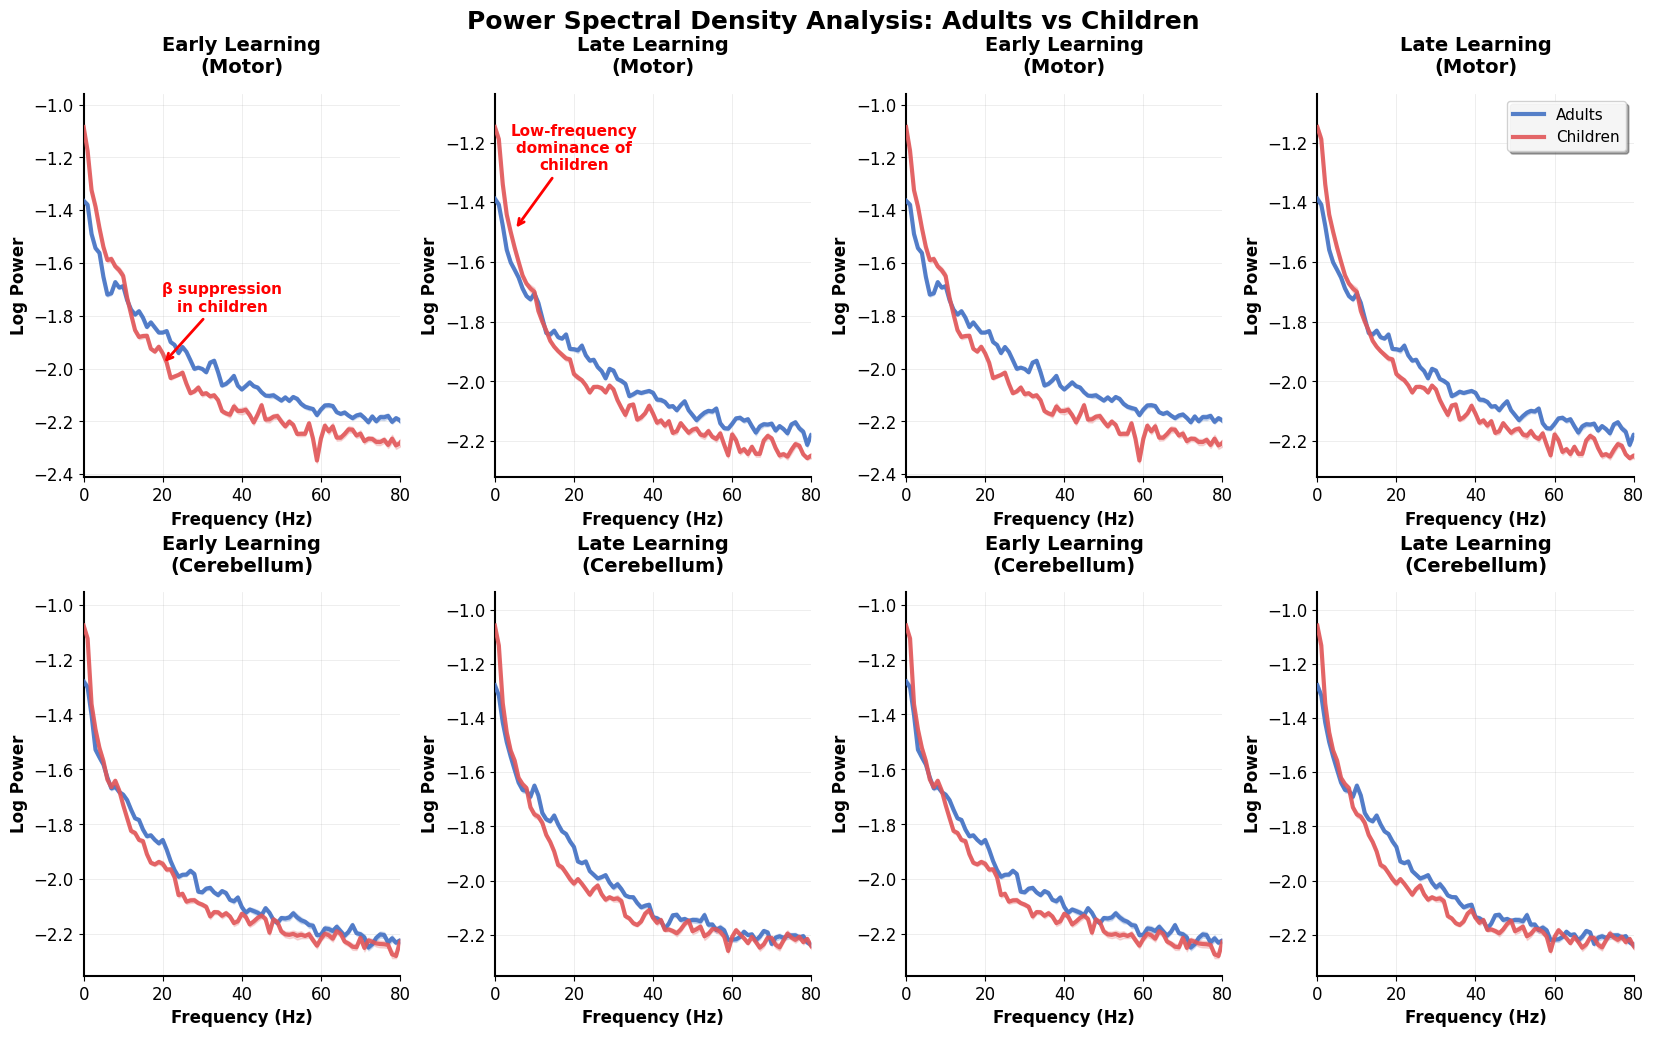

<Figure size 1600x1000 with 0 Axes>

In [37]:
fig = plt.figure(figsize=(20, 14)) 

gs = fig.add_gridspec(2, 4, top=0.88, bottom=0.25, hspace=0.3, wspace=0.3)

axes = []
for i in range(2):
    row_axes = []
    for j in range(4):
        ax = fig.add_subplot(gs[i, j])
        row_axes.append(ax)
    axes.append(row_axes)

fig.suptitle('Power Spectral Density Analysis: Adults vs Children', fontsize=18, fontweight='bold', y=0.94)

titles = [
    ['Early Learning\n(Motor)', 'Late Learning\n(Motor)', 'Early Learning\n(Motor)', 'Late Learning\n(Motor)'],
    ['Early Learning\n(Cerebellum)', 'Late Learning\n(Cerebellum)', 'Early Learning\n(Cerebellum)', 'Late Learning\n(Cerebellum)']
]

data_sets = [
    [(el_motor_adults, el_motor_children, el_motor_std_adults, el_motor_std_children),
     (ll_motor_adults, ll_motor_children, ll_motor_std_adults, ll_motor_std_children),
     (el_motor_adults, el_motor_children, el_motor_std_adults, el_motor_std_children),
     (ll_motor_adults, ll_motor_children, ll_motor_std_adults, ll_motor_std_children)],
    [(el_cereb_adults, el_cereb_children, el_cereb_std_adults, el_cereb_std_children),
     (ll_cereb_adults, ll_cereb_children, ll_cereb_std_adults, ll_cereb_std_children),
     (el_cereb_adults, el_cereb_children, el_cereb_std_adults, el_cereb_std_children),
     (ll_cereb_adults, ll_cereb_children, ll_cereb_std_adults, ll_cereb_std_children)]
]

sig_sets = [
    [sig_freqs_motor_age, sig_freqs_motor_cond, sig_freqs_motor_int],
    [sig_freqs_cereb_age, sig_freqs_cereb_cond, sig_freqs_cereb_int]
]

all_significance_data = {
    'motor': [sig_freqs_motor_age, sig_freqs_motor_cond, sig_freqs_motor_int],
    'cerebellum': [sig_freqs_cereb_age, sig_freqs_cereb_cond, sig_freqs_cereb_int]
}

for row in range(2):
    for col in range(4):
        adults_data, children_data, adults_std, children_std = data_sets[row][col]
        sig_age, sig_cond, sig_int = sig_sets[row]
        
        show_legend = (row == 0 and col == 3)
        add_annotations = (col < 2)
        
        plot_psd_with_external_significance(axes[row][col], freqs, adults_data, children_data, 
                                          adults_std, children_std, sig_age, sig_cond, sig_int,
                                          titles[row][col], show_legend=show_legend, 
                                          add_annotations=add_annotations)

plt.show()

plt.savefig('PSD_Analysis_External_Significance.pdf', dpi=300, bbox_inches='tight')
plt.savefig('PSD_Analysis_External_Significance.png', dpi=300, bbox_inches='tight')